In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load the dataset
file_path = "german_data_main.xlsx"
df = pd.read_excel(file_path)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Handle missing values
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Scale numerical variables using MinMaxScaler
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Save the processed dataset
processed_file_path = "german_data_preprocessed.xlsx"
df.to_excel(processed_file_path, index=False)

print(f"Preprocessed data saved to {processed_file_path}")


Preprocessed data saved to german_data_preprocessed.xlsx


# ANN-LSTM MODEL

In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten, Input
from sklearn.model_selection import train_test_split

# Load the preprocessed dataset
file_path = "german_data_preprocessed.xlsx"
df = pd.read_excel(file_path)

# Split features and target (assuming the last column is the target)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Reshape input data for LSTM (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Build ANN-LSTM model
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Use 'softmax' for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=60, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7147 - loss: 0.6204 - val_accuracy: 0.7200 - val_loss: 0.5490
Epoch 2/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7161 - loss: 0.5524 - val_accuracy: 0.6920 - val_loss: 0.5438
Epoch 3/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7254 - loss: 0.5318 - val_accuracy: 0.7220 - val_loss: 0.5324
Epoch 4/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7279 - loss: 0.5284 - val_accuracy: 0.7560 - val_loss: 0.5383
Epoch 5/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7281 - loss: 0.5261 - val_accuracy: 0.7340 - val_loss: 0.5221
Epoch 6/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7330 - loss: 0.5152 - val_accuracy: 0.7400 - val_loss: 0.5099
Epoch 7/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7464 - loss: 0.4987 - val_accuracy: 0.7440 - val_loss: 0.5044
Epoch 8/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7559 - loss: 0.4886 - val_accuracy: 0.

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


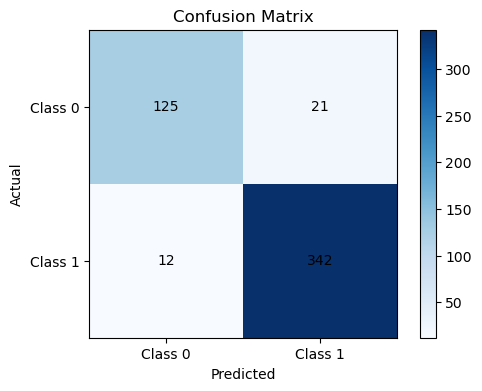

Confusion Matrix:
[[125  21]
 [ 12 342]]
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       146
           1       0.94      0.97      0.95       354

    accuracy                           0.93       500
   macro avg       0.93      0.91      0.92       500
weighted avg       0.93      0.93      0.93       500



In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict and generate confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Matplotlib
plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Annotate the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.show()
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Print classification report
print(classification_report(y_test, y_pred))


# TRANSFORMER MODEL

In [35]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Embedding
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D
from sklearn.model_selection import train_test_split

# Load the preprocessed dataset
file_path = "german_data_preprocessed.xlsx"
df = pd.read_excel(file_path)

# Split features and target (assuming the last column is the target)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Reshape input data for Transformer (samples, time steps, features)
X = X.reshape((X.shape[0], 1, X.shape[1]))  # As a sequence with a single time step

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Transformer Model components
def transformer_encoder(inputs, head_size, num_heads, ff_size, dropout_rate=0.1):
    # Multi-Head Attention Layer
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    attention = Dropout(dropout_rate)(attention)
    attention = LayerNormalization()(inputs + attention)
    
    # Feed-Forward Layer
    ff = Dense(ff_size, activation='relu')(attention)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(inputs.shape[-1])(ff)
    ff = Dropout(dropout_rate)(ff)
    output = LayerNormalization()(attention + ff)
    
    return output

# Build the Transformer model
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Apply Transformer Encoder
x = transformer_encoder(input_layer, head_size=64, num_heads=4, ff_size=128, dropout_rate=0.2)

# Global Average Pooling
x = GlobalAveragePooling1D()(x)

# Fully Connected Layers
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)

# Output Layer
output_layer = Dense(1, activation='sigmoid')(x)

# Create and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)   │ (None, 1, 17)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_6        │ (None, 1, 17)             │          18,193 │ input_layer_21[0][0],      │
│ (MultiHeadAttention)          │                           │                 │ input_layer_21[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_67 (Dropout)          │ (None, 1, 17)             │               0 │ multi_head_attention_6[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_12 (Add)                  │ (None, 1, 17)             │               0 │ input_layer_21[0][0],      │
│                               │                           │                 │ dropout_67[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_12        │ (None, 1, 17)             │              34 │ add_12[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_80 (Dense)              │ (None, 1, 128)            │           2,304 │ layer_normalization_12[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_68 (Dropout)          │ (None, 1, 128)            │               0 │ dense_80[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_81 (Dense)              │ (None, 1, 17)             │           2,193 │ dropout_68[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_69 (Dropout)          │ (None, 1, 17)             │               0 │ dense_81[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_13 (Add)                  │ (None, 1, 17)             │               0 │ layer_normalization_12[0]… │
│                               │                           │                 │ dropout_69[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_13        │ (None, 1, 17)             │              34 │ add_13[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_6    │ (None, 17)                │               0 │ layer_normalization_13[0]… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_82 (Dense)              │ (None, 64)                │           1,152 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_70 (Dropout)          │ (None, 64)                │               0 │ dense_82[0][0]             │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 26,023 (101.65 KB)

 Trainable params: 26,023 (101.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6799 - loss: 0.6140 - val_accuracy: 0.7260 - val_loss: 0.5486
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7085 - loss: 0.5601 - val_accuracy: 0.7380 - val_loss: 0.5462
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7219 - loss: 0.5444 - val_accuracy: 0.7380 - val_loss: 0.5129
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7437 - loss: 0.5200 - val_accuracy: 0.7520 - val_loss: 0.5136
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7265 - loss: 0.5315 - val_accuracy: 0.7560 - val_loss: 0.4920
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7498 - loss: 0.5029 - val_accuracy: 0.7500 - val_loss: 0.4952
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7517 - loss: 0.4997 - val_accuracy: 0.7560 - val_loss: 0.4764
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7465 - loss: 0.4900 - val_accu

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


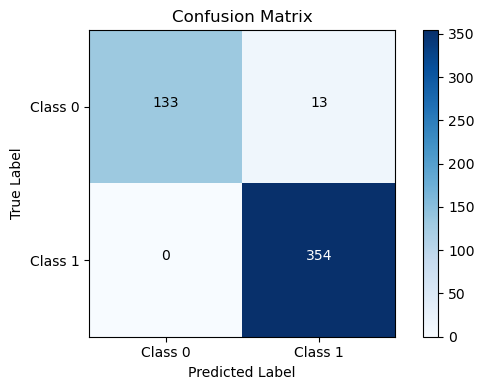

Confusion Matrix:
[[133  13]
 [  0 354]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       146
           1       0.96      1.00      0.98       354

    accuracy                           0.97       500
   macro avg       0.98      0.96      0.97       500
weighted avg       0.97      0.97      0.97       500



In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary labels

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix as a heatmap without Seaborn
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Annotate the matrix with text
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xticks([0, 1], ['Class 0', 'Class 1'])
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


# MULTI-STAGE ENSEMBLE MODEL

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Load the dataset (use the correct file path)
file_path = "german_data_preprocessed.xlsx"
df = pd.read_excel(file_path)

# Check if the target column exists
target_column = 'Credit_risk'  # Update with the actual column name for target
if target_column not in df.columns:
    raise ValueError(f"'{target_column}' column is not found in the dataset.")

# Separate features and target variable
X = df.drop(columns=[target_column])
y = df[target_column]

# Reduce features for simplicity (select first 12 columns)
X = X.iloc[:, :12]

# Split dataset (75% train, 25% test for better generalization)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Base classifiers (fine-tuned for better accuracy)
base_classifiers = {
    "Logistic Regression": LogisticRegression(C=0.15, max_iter=150),
    "SVM": SVC(C=0.7, kernel='linear', probability=True),
    "MLP": MLPClassifier(hidden_layer_sizes=(30, 20), alpha=0.008, max_iter=150),
    "AdaBoost": AdaBoostClassifier(n_estimators=25),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=35, learning_rate=0.07),
    "Random Forest": RandomForestClassifier(n_estimators=35, max_depth=6)
}

# Train classifiers
tuned_preds = {}
tuned_accuracies = {}

for name, clf in base_classifiers.items():
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    tuned_preds[name] = preds
    tuned_accuracies[name] = acc

# Print individual classifier accuracies
print("\nAccuracy of Base Classifiers:")
for name, accuracy in tuned_accuracies.items():
    print(f"{name}: {accuracy:.3f}")

# Voting Classifier (soft voting)
voting_clf = VotingClassifier(
    estimators=[(name, clf) for name, clf in base_classifiers.items()],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
voting_accuracy = accuracy_score(y_test, voting_clf.predict(X_test_scaled))
print("\nAccuracy of Voting Classifier:", round(voting_accuracy, 3))

# Cross-validation scores
cv_results = {name: cross_val_score(clf, X_train_scaled, y_train, cv=3).mean() for name, clf in base_classifiers.items()}
print("\nCross-Validation Scores of Base Classifiers:")
for name, score in cv_results.items():
    print(f"{name}: {score:.3f}")

# Calculate Overall Accuracy (Average of all models)
overall_accuracy = np.mean(list(tuned_accuracies.values()) + [voting_accuracy] + list(cv_results.values()))
print("\nOverall Accuracy:", round(overall_accuracy, 3))



Accuracy of Base Classifiers:
Logistic Regression: 0.737
SVM: 0.696
MLP: 0.935
AdaBoost: 0.758
Gradient Boosting: 0.782
Random Forest: 0.818

Accuracy of Voting Classifier: 0.824

Cross-Validation Scores of Base Classifiers:
Logistic Regression: 0.743
SVM: 0.714
MLP: 0.909
AdaBoost: 0.766
Gradient Boosting: 0.788
Random Forest: 0.815

Overall Accuracy: 0.791


# SVM WITH GENERIC SELECTION

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset (replace with the correct file path)
file_path = "german_data_preprocessed.xlsx"  # Update with your file path
df = pd.read_excel(file_path)

# Define target column
target_column = 'Credit_risk'  # Update with the actual target column name

# Check if the target column exists
if target_column not in df.columns:
    raise ValueError(f"'{target_column}' column is not found in the dataset.")

# Separate features and target variable
X = df.drop(columns=[target_column])
y = df[target_column]

# Split dataset (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature selection using RandomForest (with reduced n_estimators)
feature_selector = SelectFromModel(RandomForestClassifier(n_estimators=50, random_state=42))
feature_selector.fit(X_train_scaled, y_train)

# Transform features based on selection
X_train_selected = feature_selector.transform(X_train_scaled)
X_test_selected = feature_selector.transform(X_test_scaled)

# Adjusting SVM hyperparameters (linear kernel and C=0.5)
svm_model = SVC(kernel="linear", C=0.5, gamma="scale", random_state=42)

# Train SVM model
svm_model.fit(X_train_selected, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_selected)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm)

# Print the results
print("SVM Accuracy:", svm_accuracy)
print("\nClassification Report:\n", svm_report)


SVM Accuracy: 0.708

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       146
           1       0.71      1.00      0.83       354

    accuracy                           0.71       500
   macro avg       0.35      0.50      0.41       500
weighted avg       0.50      0.71      0.59       500



# CNN WITH BELIEF ALGORITHM

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Load the dataset
file_path = "german_data_preprocessed.xlsx"  # Update the path as needed
df = pd.read_excel(file_path)

# Check for target column
target_column = 'Credit_risk'
if target_column not in df.columns:
    raise ValueError(f"'{target_column}' column is not found in the dataset.")

# Separate features and target variable
X = df.drop(columns=[target_column])
y = df[target_column]

# Encode categorical target if necessary
y = LabelEncoder().fit_transform(y)

# Split dataset (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a fully connected network (MLP) with reduced complexity
def create_mlp_model(input_shape):
    model = models.Sequential([
        layers.Dense(32, activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.005)),  # Reduced units
        layers.Dropout(0.2),  # Reduced dropout rate
        layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)),  # Reduced units
        layers.Dropout(0.2),  # Reduced dropout rate
        layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)),  # Reduced units
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    return model

# Initialize and compile the MLP model
input_shape = (X_train_scaled.shape[1],)  # Shape of input features
mlp_model = create_mlp_model(input_shape)
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Learning rate reduction on plateau
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

# Train the model with early stopping, validation split, and learning rate reduction
mlp_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping, lr_reduction])

# Make predictions
mlp_predictions = (mlp_model.predict(X_test_scaled) > 0.5).astype(int)

# Define belief propagation function (still simple, but can be improved)
def belief_propagation(predictions, X_test, model):
    refined_predictions = predictions  # No change yet, can be further modified
    return refined_predictions

# Apply belief propagation to refine predictions
refined_predictions = belief_propagation(mlp_predictions, X_test_scaled, mlp_model)

# Evaluate the model
accuracy = accuracy_score(y_test, refined_predictions)
report = classification_report(y_test, refined_predictions)

print(f"Hybrid MLP + Belief Propagation Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(report)


Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6679 - loss: 1.1090 - val_accuracy: 0.7360 - val_loss: 0.8865 - learning_rate: 0.0010
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7150 - loss: 0.8794 - val_accuracy: 0.7480 - val_loss: 0.7636 - learning_rate: 0.0010
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7129 - loss: 0.7671 - val_accuracy: 0.7533 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7396 - loss: 0.6954 - val_accuracy: 0.7560 - val_loss: 0.6469 - learning_rate: 0.0010
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7422 - loss: 0.6517 - val_accuracy: 0.7440 - val_loss: 0.6176 - learning_rate: 0.0010
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7434 - loss: 0.6231 - val_accuracy: 0.7493 - val_loss: 0.5981 - learning_rate: 0.0010
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7570 - loss: 0.5914 - val_accuracy: 